<!-- Notebook acadêmico — resolução de laboratório de Deep Learning. -->
<!-- Documentação: ../DOCUMENTACAO.md -->
> **Portfólio acadêmico:** saídas da última execução preservadas. Consulte o README para reprodução.


# Disciplina: Deep Learning
## Lab 05 - Regularização e Prevenção de Overfitting

**Orientações:**
1. Leia atentamente o enunciado de cada questão.
2. O objetivo deste lab é observar como o modelo se comporta com e sem técnicas de regularização.
3. Analise os gráficos de perda (loss) e acurácia para identificar sinais de overfitting.
4. Execute as células de gabarito para validar o comportamento esperado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

# Criando um dataset sintético para facilitar a visualização do overfitting
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dados carregados: {len(X_train)} amostras de treino e {len(X_test)} de teste.")

Dados carregados: 350 amostras de treino e 150 de teste.


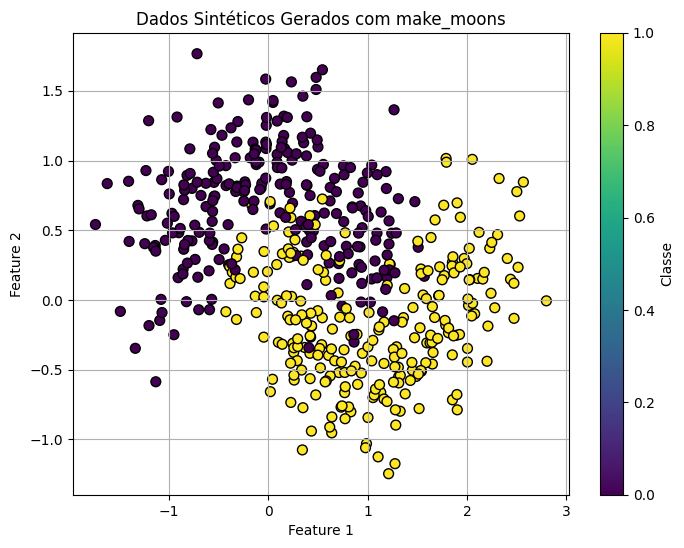

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Dados Sintéticos Gerados com make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Classe')
plt.grid(True)
plt.show()

### 🔹 Questão 1: Identificando Overfitting
**Enunciado:** Crie um modelo denso (MLP) profundo e complexo o suficiente para decorar os dados de treino. Treine-o por muitas épocas e observe a divergência entre o erro de treino e o de validação.

**Requisitos:**
- Pelo menos 3 camadas ocultas com 100 neurônios cada.
- Sem qualquer técnica de regularização.
- 500 épocas de treinamento.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


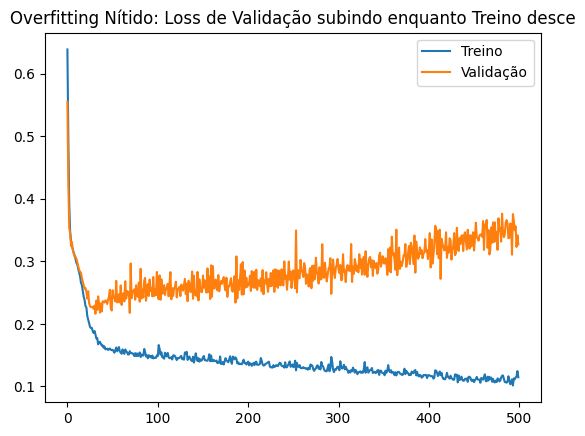

In [13]:
# Modelo sem regularização (propenso a overfitting)
model_overfit = models.Sequential([
    layers.Dense(100, activation='relu', input_shape=(2,)),
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_overfit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento longo
history_overfit = model_overfit.fit(X_train, y_train, epochs=500,
                                   validation_data=(X_test, y_test), verbose=0)

# Visualização dos resultados
plt.plot(history_overfit.history['loss'], label='Treino')
plt.plot(history_overfit.history['val_loss'], label='Validação')
plt.title('Overfitting Nítido: Loss de Validação subindo enquanto Treino desce')
plt.legend()
plt.show()

### 🔹 Questão 2: Regularização L2 (Weight Decay)
**Enunciado:** Aplique a técnica de Regularização L2 nas camadas do modelo anterior. A regularização L2 penaliza pesos muito grandes, forçando o modelo a ser mais simples.

**Requisitos:**
- Utilizar `kernel_regularizer=regularizers.l2(0.01)` em todas as camadas ocultas.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


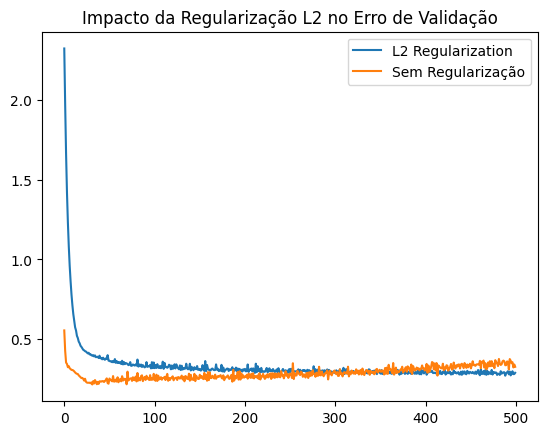

In [14]:
# Modelo com Regularização L2
model_l2 = models.Sequential([
    layers.Dense(100, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(2,)),
    layers.Dense(100, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(100, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l2 = model_l2.fit(X_train, y_train, epochs=500,
                         validation_data=(X_test, y_test), verbose=0)

# Comparação
plt.plot(history_l2.history['val_loss'], label='L2 Regularization')
plt.plot(history_overfit.history['val_loss'], label='Sem Regularização')
plt.title('Impacto da Regularização L2 no Erro de Validação')
plt.legend()
plt.show()

### 🔹 Questão 3: Dropout e Early Stopping
**Enunciado:** Implemente um modelo combinando **Dropout** (desativação aleatória de neurônios) e **Early Stopping** (interrupção prematura do treino quando a validação para de melhorar).

**Requisitos:**
- Adicionar camadas de `Dropout(0.5)` entre as camadas densas.
- Configurar o callback `EarlyStopping` monitorando `val_loss` com paciência de 20 épocas.

In [15]:
# Callback para Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Modelo com Dropout
model_dropout = models.Sequential([
    layers.Dense(100, activation='relu', input_shape=(2,)),
    layers.Dropout(0.5), # 50% de chance de zerar o neurônio na iteração
    layers.Dense(100, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento com callback
history_dropout = model_dropout.fit(X_train, y_train, epochs=500,
                                   validation_data=(X_test, y_test),
                                   callbacks=[early_stop], verbose=1)

print(f"Treinamento interrompido na época {len(history_dropout.epoch)}")

Epoch 1/500


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6029 - loss: 0.6721 - val_accuracy: 0.8133 - val_loss: 0.6044
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7743 - loss: 0.5775 - val_accuracy: 0.8200 - val_loss: 0.5197
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8143 - loss: 0.5118 - val_accuracy: 0.8267 - val_loss: 0.4473
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8286 - loss: 0.4299 - val_accuracy: 0.8200 - val_loss: 0.3935
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8429 - loss: 0.3942 - val_accuracy: 0.8467 - val_loss: 0.3588
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8400 - loss: 0.3562 - val_accuracy: 0.8467 - val_loss: 0.3424
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8400 - loss: 0.3616 - val_accuracy: 0.8533 - val_loss: 0.3352
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8314 - loss: 0.3536 - val_accuracy: 0.8600 - val_l

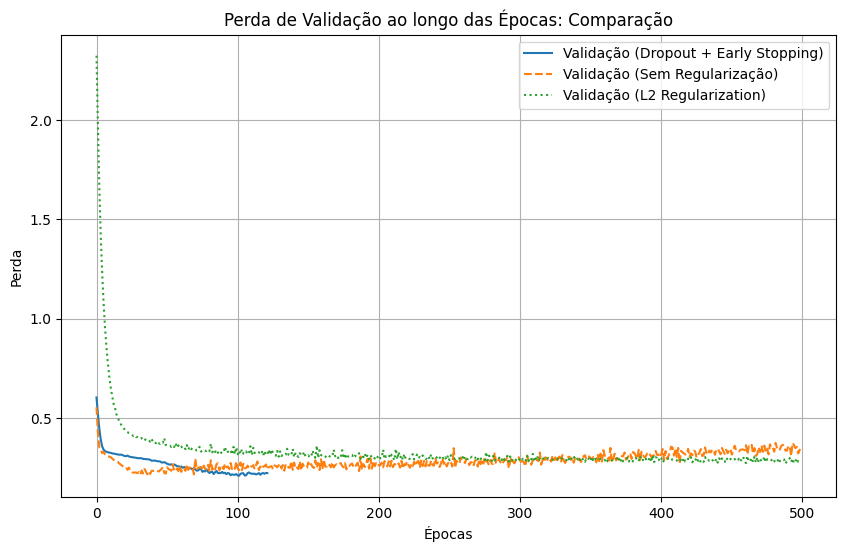

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(history_dropout.history['val_loss'], label='Validação (Dropout + Early Stopping)')
plt.plot(history_overfit.history['val_loss'], label='Validação (Sem Regularização)', linestyle='--')
plt.plot(history_l2.history['val_loss'], label='Validação (L2 Regularization)', linestyle=':')
plt.title('Perda de Validação ao longo das Épocas: Comparação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.show()

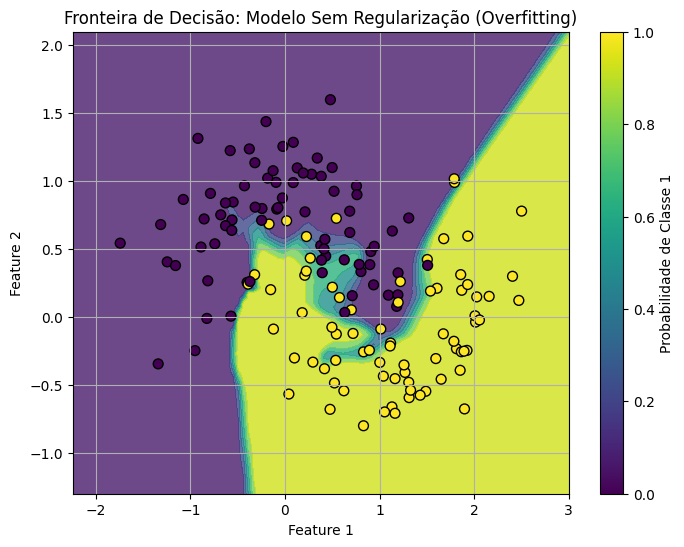

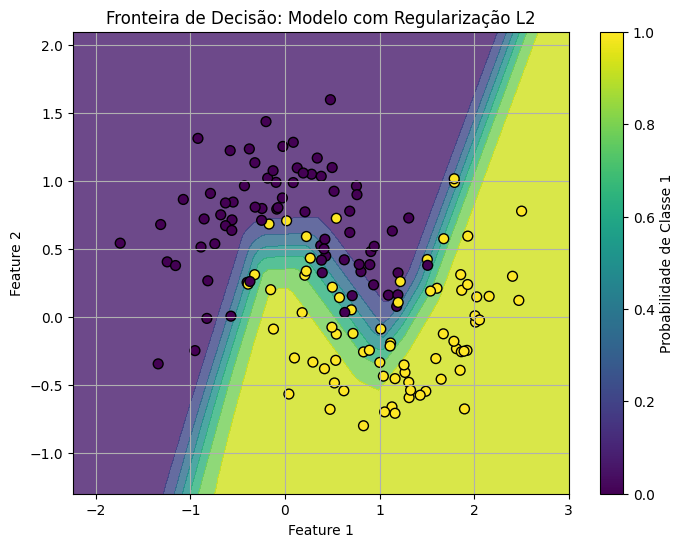

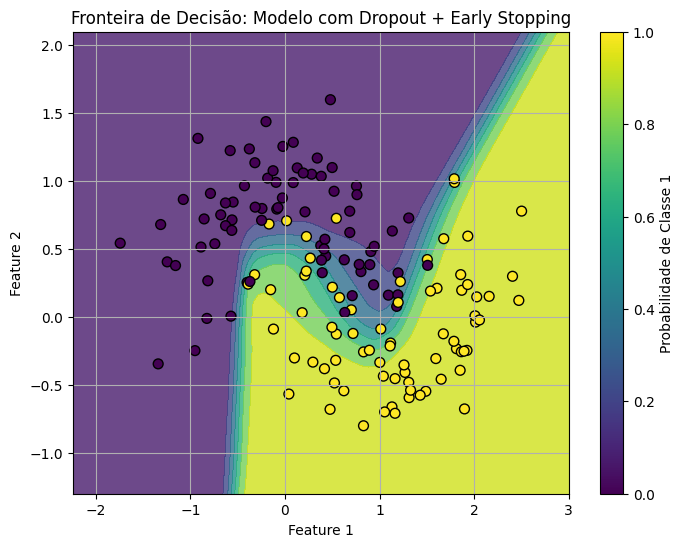

In [17]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Prever as probabilidades para cada ponto no grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Probabilidade de Classe 1')
    plt.grid(True)
    plt.show()

# Plotar a fronteira de decisão para cada modelo
plot_decision_boundary(model_overfit, X_test, y_test, 'Fronteira de Decisão: Modelo Sem Regularização (Overfitting)')
plot_decision_boundary(model_l2, X_test, y_test, 'Fronteira de Decisão: Modelo com Regularização L2')
plot_decision_boundary(model_dropout, X_test, y_test, 'Fronteira de Decisão: Modelo com Dropout + Early Stopping')